# Stretching of a passive cube

**Joakim Sundnes, Ingvild Devold and Jørgen S. Dokken**


* Solve a simple soft tissue mechanics problem:
  * Elastic unit cube
  * Uniaxial stretch
  * St Venant-Kirchhoff material


## Recap of key quantities 
* $u(t) = x(t) - X$: Displacement, usually the primary unknown of our mechanics problems. 
* ${F} = {I} + \nabla{u}$: Deformation gradient. Used in strain definitions and to map between deformed and undeformed geometries.
* ${C} = {F}^T{F}$: Right Cauchy-Green tensor. Measure of pure deformation, free of rigid body translation and rotation, often used in constitutive laws. Not technically strain since ${C} = {I}$ for zero displacement.
* ${E} = 1/2({F}^T{F}-{I}) = 1/2({C}-{I})$: Green-Lagrange strain. The most commonly used strain tensor for large deformations. Extension of the standard, linear small deformation strain.
* ${\sigma}$: Cauchy stress tensor, also called the true stress. Standard stress tensor used for small deformations. Relevant also for large deformations, but inconvenient to use in computations. 
* ${P}, {S}$: First and second Piola-Kirchhoff stress tensors. Stress tensors suitable for large deformations, since they are defined relative to the undeformed geometry. 
* $W$: Strain energy function. Defines the elastic energy stored during a deformation. Used to define material laws, since stress is recovered as ${S} = \partial W/\partial{E}$, etc.



# Example 1: An elastic cube
We start with a simple example, where we consider loading of a unit cube. This simple case will illustrate how to define a non-linear elasticity problem in FEniCSx, and how to introduce boundary conditions and different material properties. The model will be a simple unit cube, fixed at one end ($x=0$) and loaded with a pressure load (stretch) at the other end ($x=1.0$). The first version of the model will use a simple isotropic neo-Hookean material model. Later we will introduce a more realistic soft tissue model, and also add active contraction. 


## Weak form of the static hyperelasticity problem
We want to solve a static solid mechanics problem with a combination of Dirichlet and Neumann boundary conditions:

$$
\begin{align*}
    - \nabla\cdot P &= 0 && \quad \text{ in } \Omega \\
    u &= 0 && \quad \text{ on } \Gamma_{\mathrm{D}} \\
    P \cdot n &= T && \quad \text{ on } \Gamma_{\mathrm{N}} \\
    P \cdot n &= 0 && \quad \text{ on } \Gamma_{\mathrm{0}}
\end{align*}
$$

Here, $P$ is the first Piola-Kirchhoff stress tensor, $u$ is the displacement, $T$ is a load (vector) applied to parts of the boundary, and $\Omega, \Gamma_{\mathrm{D}}, \Gamma_{\mathrm{N}},\Gamma_{\mathrm{0}}$ are the domain and the boundaries for Dirichlet- and Neumann boundary conditions, respectively. 

To apply the finite element method, we need to derive the weak form of the problem.  Multiply by a test function $v \in \hat{V}$ and integrate by parts:

$$
\begin{equation}
    - \int_{\Omega} \nabla\cdot P \cdot v dx
    = \int_{\Omega} P : \nabla v dx - \int_{\partial\Omega} (P \cdot n) \cdot v ds = 0
\end{equation}
$$ (eq:weak-form)

We now apply the boundary conditions (and note that $v = 0$ on $\Gamma_{\mathrm{D}}$), to get the final weak form:

Find $u \in V$ such that
\begin{equation*}
    \int_{\Omega} P : \nabla v dx
    = \int_{\Gamma_{\mathrm{N}}} T \cdot v ds
\end{equation*}
for all $v \in \hat{V}$.

In our case, the boundary load $T$ is a simple normal pressure. If we were working in the deformed configuration, we would simply have $T=-p n$, where $p$ is the applied pressure and $n$ is the unit surface normal. However, we are using a Lagrangian formulation and everything is defined relative to the reference state. The applied pressure, which actually acts on the deformed surface, therefore needs to be mapped to the reference state. We get
\begin{equation*}
    T = -p J F^{-T}\cdot N,
\end{equation*}
where $N$ is the unit normal of the undeformed (reference) geometry. 

## The St Venant-Kirchhoff material model
The simplest hyperelastic material model is the St Venant-Kirchhoff model, which is simply an extension of the linear Hooke's law to the large-deformation regime. The strain energy function is given by:

$$
\begin{equation*}
    W(E) = \frac{\lambda}{2} (\operatorname{tr}(E))^2 + \mu \operatorname{tr}(E^2),
\end{equation*}
$$ (eq:stvk)

where $E = \frac{1}{2}(F^T F - I)$ is the Green-Lagrange strain, and $F = I + \nabla u$ is the deformation gradient.
For the material (Lamé) parameters, we use values $\mu=4.0$ and $\lambda=20.0$.
From the strain energy function we can obtain the first and second Piola-Kirchhoff (PK) stress ($P$ and $S$) as

$$
\begin{align*}
P_{ij} &= \frac{\partial W}{\partial F_{ij}}, \\
S_{ij} &= \frac{\partial W}{\partial E_{ij}},
\end{align*}
$$

and we also have the relation $P = FS$. Both the first and second PK stresses are commonly used in finite element solvers. The formulation based on $S$ is popular in text books, as it allows a few more analytical steps in the derivation of the nonlinear solution method. However, in a computational setting, and in particular when using an automated system like FEniCSx, the formulation based on $P$ is just as simple.

## The FEniCS solver
We are now ready to specify the problem in FEniCS. First, the usual imports and defining the solution domain, the function space, and various functions from the {py:mod}`Unified Form Language<ufl>`:

In [1]:
from dolfinx import fem, mesh, plot, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
from ufl import (
    TestFunction,
    Measure,
    FacetNormal,
    variable,
    Identity,
    grad,
    diff,
    dot,
    inner,
    tr,
    det,
    inv,
    dx,
)
from mpi4py import MPI
from scifem import evaluate_function
from matplotlib import pyplot as plt
import numpy as np
import pyvista
from plotting import setup_gif_visualizer, update_gif_frame

We start by creating our {py:func}`unit cube domain<dolfinx.mesh.create_unit_cube>`:

2026-05-28 14:23:53.188 (   0.285s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:251   WARN| Setting an EGL display to device index: -1 require EGL_EXT_device_base EGL_EXT_platform_device EGL_EXT_platform_base extensions
2026-05-28 14:23:53.188 (   0.285s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:257   WARN| Attempting to use the default egl display for the current platform...
2026-05-28 14:23:53.188 (   0.285s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:263   WARN| Could not initialize a device. Exiting...
2026-05-28 14:23:53.188 (   0.285s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:307   WARN| Could not set device as display. EGL_EXT_device_base, EGL_EXT_platform_device and EGL_EXT_platform_base extensions are required.
2026-05-28 14:23:53.188 (   0.285s) [    FFFF99AFCBA0]vtkOpenGLRenderWindow.c:919   WARN| vtkEGLRenderWindow (0xaaaafe90bf50): Failed to initialize OpenGL functions!
2026-05-28 14:23:53.188 (   0.285s) [    FFFF99AFCBA0]vtkOpenGLRenderWindow.c:667   WARN| Failed to creat

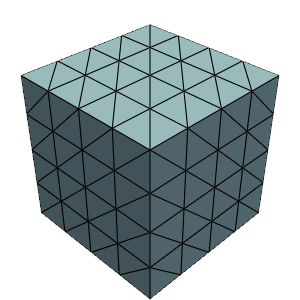

In [2]:
# Create the mesh and the function space for the solutions
domain = mesh.create_unit_cube(MPI.COMM_WORLD, 4, 4, 4)

# Plot mesh with Pyvista
pyvista.set_jupyter_backend("static")
pv_grid = pyvista.UnstructuredGrid(*plot.vtk_mesh(domain))
plotter = pyvista.Plotter(window_size=[300, 300])
plotter.add_mesh(pv_grid, show_edges=True)
plotter.show()

Next, we define the function space, displacement $u$ and test function $v$, using a second order discretization:

In [3]:
V = fem.functionspace(domain, ("Lagrange", 2, (domain.geometry.dim,)))
u = fem.Function(V, name="u")  # Displacement
v = TestFunction(V)  # Test function

Note that we have defined our unknown displacement as a {py:class}`dolfinx.fem.Function`, rather than {py:func}`ufl.TrialFunction`.
This is due to the fact that the finite element formulation {eq}`eq:weak-form`, {eq}`eq:stvk` we are using is nonlinear with respect to the displacement `u`.

Now we need to define the boundary conditions. We want homogenous Dirichlet conditions on the left boundary (where $x=0.0$), a non-homogenous Neumann condition on the right boundary (where $x=1.0$), and homogenous Neumann conditions everywhere else. The following code first defines the subdomains and marks the respective boundaries, then redefines the {py:class}`boundary measure<ufl.Measure>` `ds` to allow surface integrals over parts of the boundary, and finally defines the Dirichlet conditions.

In [4]:
# Define marker functions for the left and right boundaries
def left(x):
    return np.isclose(x[0], 0)


def right(x):
    return np.isclose(x[0], 1.0)


# Locate the degrees of freedom and facets on the left and right boundaries
fdim = domain.topology.dim - 1
facets_l = mesh.locate_entities_boundary(domain, fdim, left)
dofs_l = fem.locate_dofs_topological(V, fdim, facets_l)

facets_r = mesh.locate_entities_boundary(domain, fdim, right)
dofs_r = fem.locate_dofs_topological(V, fdim, facets_r)

# Generate the meshtags, tagging the left and right boundaries with different markers
marker_l = 1
marker_r = 2

# Get ownership information regarding facets
facet_map = domain.topology.index_map(fdim)
num_facets = facet_map.size_local + facet_map.num_ghosts
facet_values = np.full(num_facets, -1, dtype=np.int32)
facet_values[facets_l] = marker_l
facet_values[facets_r] = marker_r
boundary_markers = mesh.meshtags(
    domain,
    fdim,
    np.arange(num_facets, dtype=np.int32),
    facet_values,
)

# Define boundary measure
ds = Measure("ds", domain, subdomain_data=boundary_markers)

# Define Dirichlet boundary condition on left boundary
bc = fem.dirichletbc(np.zeros(3, dtype=default_scalar_type), dofs_l, V)
bcs = [bc]

Next, we turn to defining the mechanics problem. We start with the kinematics and the strain energy function defining the St Venant-Kirchhoff material, obtain the Piola-Kirchhoff stresses by differentiating the strain energy function, and finally define the weak form of the problem.

# Exercise

```{exercise} Solve the passive cube stretching problem
:label: l13-passive-cube

Continue the code below to define all relevant kinematic quantities, the St Venant-Kirchhoff strain energy and the weak form.
```

We define the deformation gradient below. Add the remaining kinetic quantities ($C$, $E$), material parameters, and strain energy function given above.

In [5]:
# Kinematics
d = len(u)
I = Identity(d)  # Identity tensor
F = I + grad(u)  # Deformation gradient

# Add code here

We now need to define the residual, which we get from moving all terms of the weak form to the left hand side. The pressure load $p$ is set to zero for now.

In [6]:
p_right = fem.Constant(domain, 0.0)  # the pressure load (zero for now)

# Add code here
# R = ...

With the residual defined, we can define the FEniCS {py:class}`NonlinearProblem<dolfinx.fem.petsc.NonlinearProblem`.
This function uses a Newton method to solve the non-linear problem, and uses symbolic differentiation to compute the Jacobian $J=\frac{\partial F}{\partial u}$.
For more information about such methods, see for instance [Solving non-linear problems by hand](https://jsdokken.com/FEniCS-workshop/src/form_compilation/alternate_form.html#hand-coded-newton-solver) or [PETSc non-linear problem interface](https://jsdokken.com/FEniCS-workshop/src/deep_dive/lifting.html#petsc-nonlinear-solver).

In [ ]:
# Set up nonlinear problem
petsc_options = {
    "snes_type": "newtonls", # Use a Newton method with the possibility of a line search
    "snes_linesearch_type": "none", # No line search by default, but can pick "bt" for backtracking line search
    "snes_error_if_not_converged": True, # Throw an error if the nonlinear solver fails to converge
    "ksp_error_if_not_converged": True, # Throw an error if the linear solver during a Newton iteration fails
    "ksp_type": "preonly", # Use a direct solver for the linear systems in each Newton iteration
    "pc_type": "lu", # Use LU factorization
    "pc_factor_mat_solver_type": "mumps", # Use the MUMPS direct solver
    # "snes_monitor": None, # uncomment to monitor convergence
}
# Uncomment
# problem = fem.petsc.NonlinearProblem(
#    R,
#    u,
#    bcs=bcs,
#    petsc_options=petsc_options,
#    petsc_options_prefix="nonlinear_cube_",
# )

Finally, we can solve the problem for different loads and plot the load vs displacement in our tracking point.

In [8]:
# Step-wise loading
load_steps = 5
target_load = 10.0
loads = np.linspace(0, target_load, load_steps)
disps = np.zeros(load_steps)

track_point = [1.0, 0.5, 0.5]

# Prepare GIF
plotter, grid, magnitude, us_expr, actor = setup_gif_visualizer(
    domain, u, filename="output/passive_cube.gif"
)

for step in range(load_steps):
    # Update traction value (stretch is a negative pressure)
    p_right.value = -loads[step]

    # Solve the nonlinear problem
    # problem.solve() Uncomment to solve

    # Evaluate displacement at point
    disps[step] = evaluate_function(u, [track_point])[0][0]

    # Write GIF frame
    update_gif_frame(plotter, grid, u, magnitude, us_expr, actor)

# Close GIF
plotter.close()

2026-05-28 14:23:53.339 (   0.435s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:251   WARN| Setting an EGL display to device index: -1 require EGL_EXT_device_base EGL_EXT_platform_device EGL_EXT_platform_base extensions
2026-05-28 14:23:53.339 (   0.435s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:257   WARN| Attempting to use the default egl display for the current platform...
2026-05-28 14:23:53.339 (   0.435s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:263   WARN| Could not initialize a device. Exiting...
2026-05-28 14:23:53.339 (   0.435s) [    FFFF99AFCBA0]vtkEGLRenderWindowInter:307   WARN| Could not set device as display. EGL_EXT_device_base, EGL_EXT_platform_device and EGL_EXT_platform_base extensions are required.
2026-05-28 14:23:53.339 (   0.436s) [    FFFF99AFCBA0]vtkOpenGLRenderWindow.c:919   WARN| vtkEGLRenderWindow (0xaaab019c3590): Failed to initialize OpenGL functions!
2026-05-28 14:23:53.340 (   0.436s) [    FFFF99AFCBA0]vtkOpenGLRenderWindow.c:667   WARN| Failed to creat

Plot the displacement vs applied load. Does the cube behave as expected?

In [9]:
# Add code here
# plt.plot(...)

The snippet above also generates a GIF visualizing the deformation using Pyvista. Run the cell below to display the GIF. 

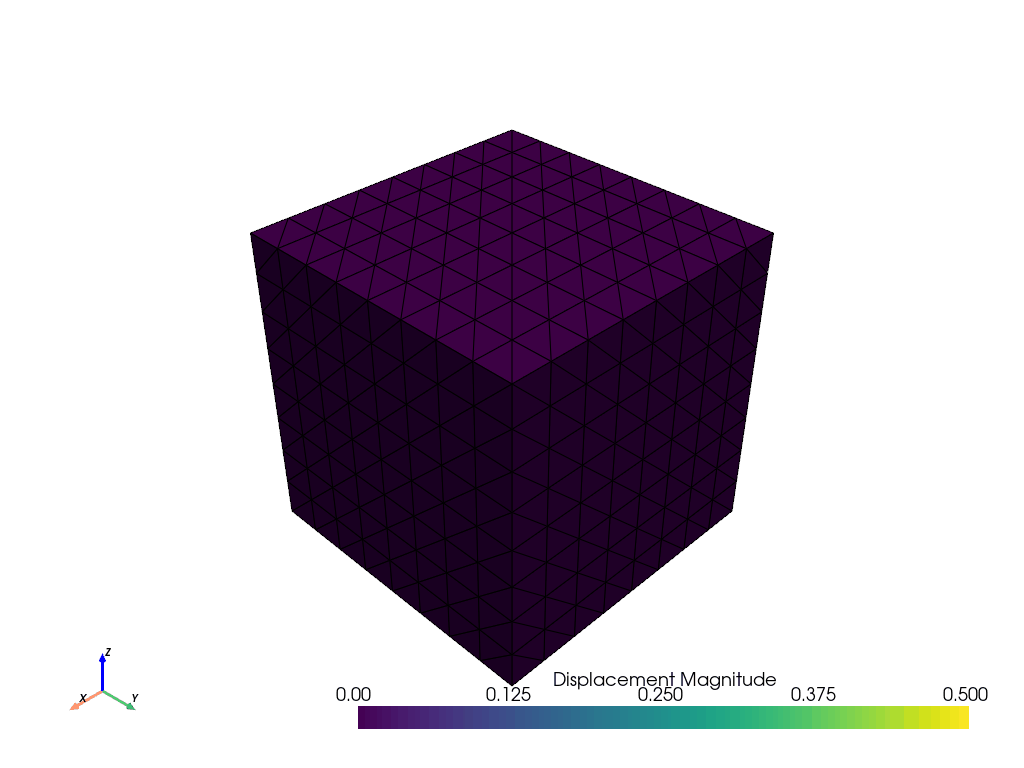

In [10]:
from IPython.display import Image
Image(filename="output/passive_cube.gif", width=500)

**Questions and comments:**
* The St Venant-Kirchhoff model is a linear stress-strain relation, but the curve above is non-linear. Why?
* An open source cardiac mechanics solver, based on the approach outlined above, can be found here: [https://github.com/finsberg/pulse](https://github.com/finsberg/pulse) (Legacy FEniCS) / [https://github.com/finsberg/fenicsx-pulse](https://github.com/finsberg/fenicsx-pulse) (FEniCSx)